# HR Predictive Pipelines

**Dataset**: `employee_data/employee_data.csv` — 1249 funcionários × 35 variáveis  
**Targets**: `MonthlyIncome` (regressão) | `Attrition` (classificação)  
**Grupo**: Group08  
**Avaliação**: R² + RMSE (regressão) · F1-score (classificação — blind test)  
**Deadline**: 18 de junho de 2026 às 23:59

In [70]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
)

_random_state = 24
DATA_PATH = Path("employee_data/employee_data.csv")

df = pd.read_csv(DATA_PATH)
print(f"Dataset: {df.shape[0]} linhas × {df.shape[1]} colunas")

Dataset: 1249 linhas × 35 colunas


## Análises do Relatório de Dados

In [71]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,No,Travel_Frequently,702,Research & Development,16,4,Life Sciences,1,838,...,3,80,0,6,3,3,5,2,1,3
1,38,No,Travel_Rarely,833,Research & Development,18,3,Medical,1,1766,...,3,80,1,15,2,3,1,0,1,0
2,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
3,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,732,...,4,80,0,10,1,3,2,2,2,2
4,23,No,Travel_Rarely,571,Research & Development,12,2,Other,1,1982,...,3,80,0,5,6,4,5,2,1,4


O dataset tem 35 colunas. Os dois alvos estão presentes: `Attrition` (texto "Yes"/"No") e `MonthlyIncome` (inteiro). Algumas colunas são identificadores ou constantes, como `EmployeeNumber`, `EmployeeCount`, `StandardHours` e `Over18`, e serão removidas antes do treino por não terem valor preditivo.

In [72]:
print(f"Shape: {df.shape}")
df.info()

Shape: (1249, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1249 non-null   int64
 1   Attrition                 1249 non-null   str  
 2   BusinessTravel            1249 non-null   str  
 3   DailyRate                 1249 non-null   int64
 4   Department                1249 non-null   str  
 5   DistanceFromHome          1249 non-null   int64
 6   Education                 1249 non-null   int64
 7   EducationField            1249 non-null   str  
 8   EmployeeCount             1249 non-null   int64
 9   EmployeeNumber            1249 non-null   int64
 10  EnvironmentSatisfaction   1249 non-null   int64
 11  Gender                    1249 non-null   str  
 12  HourlyRate                1249 non-null   int64
 13  JobInvolvement            1249 non-null   int64
 14  JobLevel                  1249 no

1249 registos, 35 colunas, sem valores nulos. Existem 26 colunas numéricas (`int64`) e 9 categóricas (`object`). Mesmo sem nulos no ficheiro original, o `SimpleImputer` é incluído no pipeline para garantir que o modelo funciona corretamente se o blind test enviar dados incompletos.

In [73]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,1249.0,37.03,9.18,18.0,30.0,36.0,43.0,60.0
DailyRate,1249.0,803.31,403.05,103.0,465.0,802.0,1157.0,1499.0
DistanceFromHome,1249.0,9.27,8.11,1.0,2.0,7.0,14.0,29.0
Education,1249.0,2.91,1.02,1.0,2.0,3.0,4.0,5.0
EmployeeCount,1249.0,1.00,0.00,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1249.0,1021.18,604.35,1.0,486.0,1011.0,1555.0,2065.0
EnvironmentSatisfaction,1249.0,2.72,1.09,1.0,2.0,3.0,4.0,4.0
HourlyRate,1249.0,65.61,20.38,30.0,48.0,66.0,83.0,100.0
JobInvolvement,1249.0,2.74,0.71,1.0,2.0,3.0,3.0,4.0
JobLevel,1249.0,2.06,1.09,1.0,1.0,2.0,3.0,5.0


`MonthlyIncome` tem média de 6482 e varia entre 1009 e 19973, com distribuição assimétrica típica de dados salariais. `EmployeeCount` e `StandardHours` são constantes em todas as linhas e não têm utilidade preditiva. As escalas das variáveis numéricas são muito diferentes entre si, o que justifica o uso de `StandardScaler` dentro do pipeline.

In [74]:
df.describe(exclude=[np.number]).T

,count,unique,top,freq
Attrition,1249,2,No,1048
BusinessTravel,1249,3,Travel_Rarely,879
Department,1249,3,Research & Development,814
EducationField,1249,6,Life Sciences,514
Gender,1249,2,Male,749
JobRole,1249,9,Sales Executive,282
MaritalStatus,1249,3,Married,573
Over18,1249,1,Y,1249
OverTime,1249,2,No,896


`Attrition` tem 84% de "No" e 16% de "Yes". Este desequilíbrio de classes justifica o uso de `class_weight='balanced'` no classificador e a escolha do F1-score como métrica de avaliação em vez de accuracy. `Over18` tem sempre o valor "Y" e será removida. `JobRole` tem 9 categorias distintas que o `OneHotEncoder` converterá em colunas binárias.

In [75]:
df.isnull().sum().sort_values(ascending=False).head(10)

Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64

Não existem valores nulos no ficheiro fornecido. O `SimpleImputer` é mantido no pipeline como medida de segurança, pois o blind test pode enviar linhas com dados em falta que o modelo terá de tratar automaticamente.

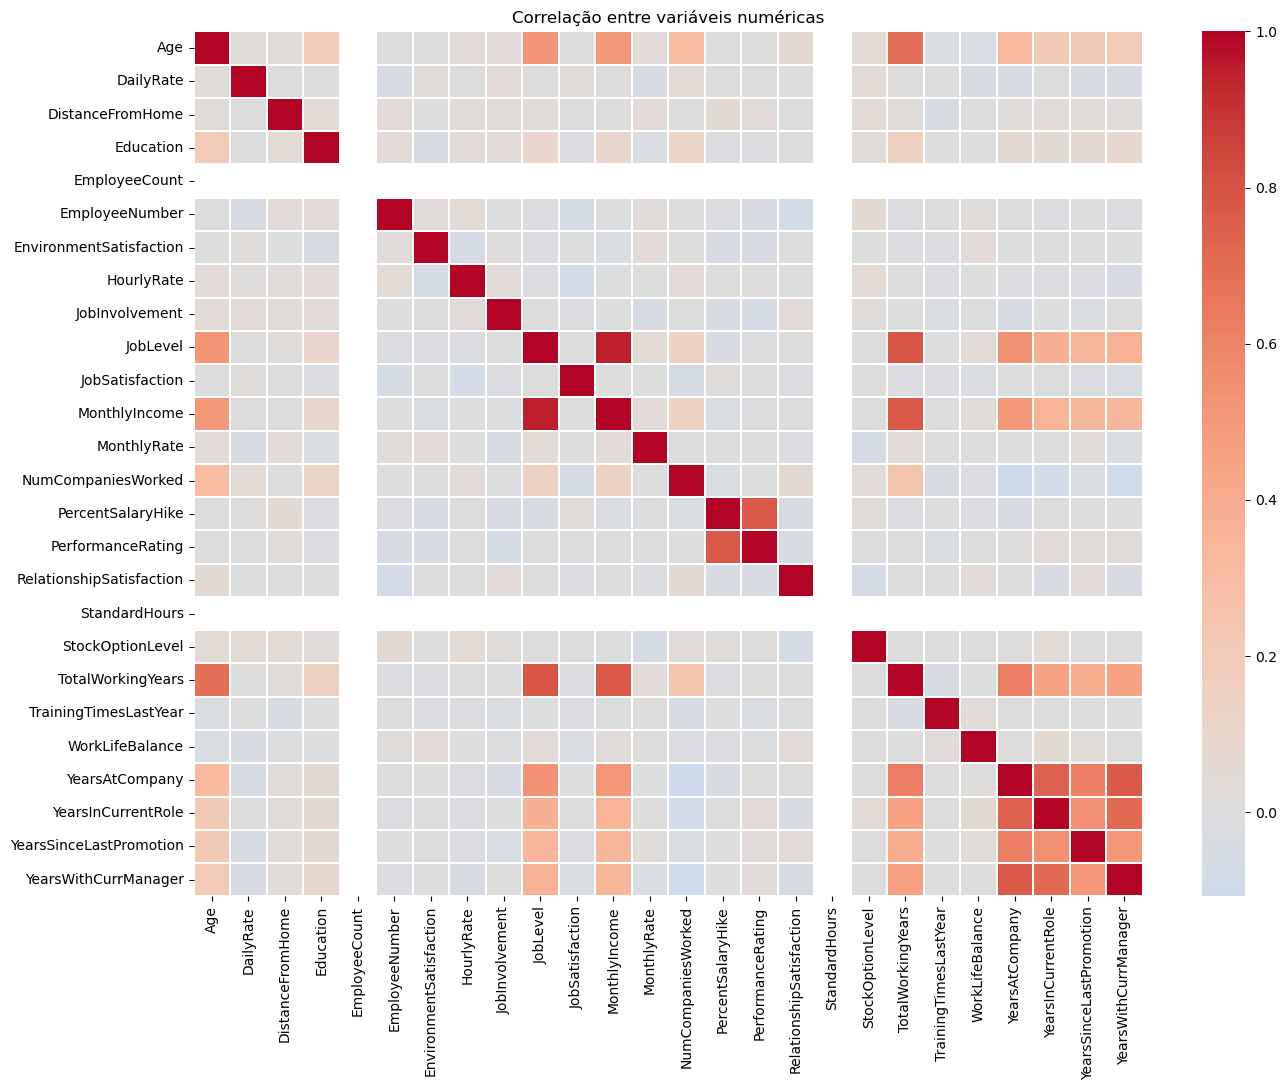

In [76]:
corr = df.select_dtypes(include="number").corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3,
            xticklabels=corr.columns, yticklabels=corr.columns, ax=ax)
ax.set_title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

`JobLevel` é a variável com maior correlação com `MonthlyIncome` (cerca de 0.95), seguida de `TotalWorkingYears` e `Age`. Estas são as features com mais peso esperado na regressão. Existem algumas correlações moderadas entre preditores, mas os modelos de árvore que vamos usar lidam bem com isso, pelo que não é necessário remover variáveis por esse motivo.

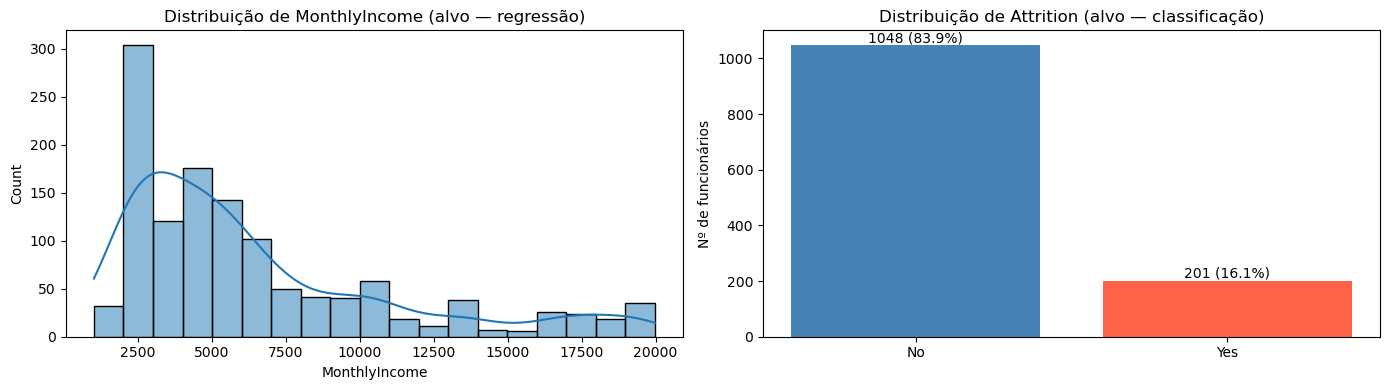

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["MonthlyIncome"], kde=True, ax=axes[0])
axes[0].set_title("Distribuição de MonthlyIncome (alvo — regressão)")
axes[0].set_xlabel("MonthlyIncome")

attrition_counts = df["Attrition"].value_counts()
axes[1].bar(attrition_counts.index, attrition_counts.values, color=["steelblue", "tomato"])
axes[1].set_title("Distribuição de Attrition (alvo — classificação)")
axes[1].set_ylabel("Nº de funcionários")
for i, v in enumerate(attrition_counts.values):
    axes[1].text(i, v + 10, f"{v} ({v/len(df)*100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

`MonthlyIncome` tem uma distribuição assimétrica à direita, com uma cauda de salários altos a afastar a média da mediana. Não aplicamos transformação logarítmica ao target porque os modelos de árvore não assumem normalidade da variável dependente. `Attrition` confirma o desequilíbrio já observado: 84% "No" e 16% "Yes", pelo que usaremos F1-score como métrica principal.

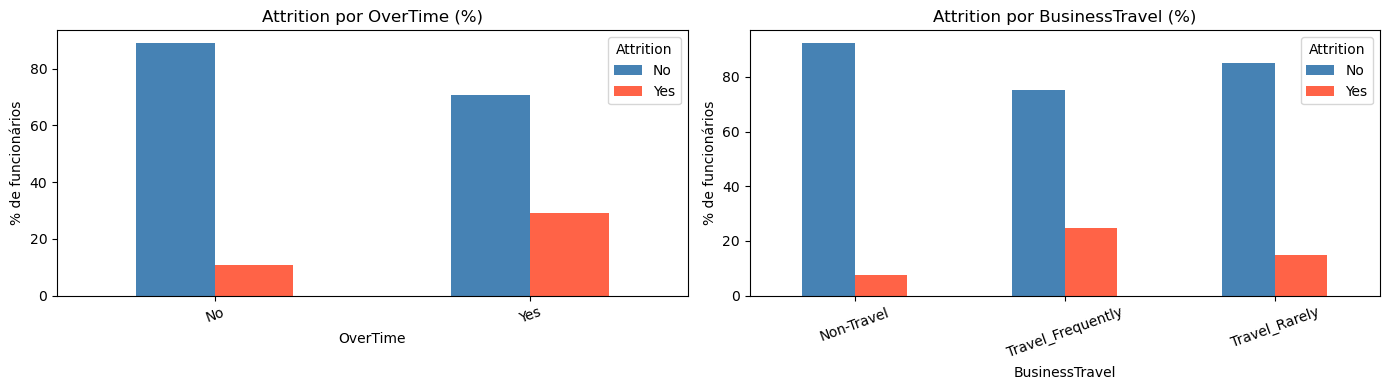

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ["OverTime", "BusinessTravel"]):
    ct = df.groupby([col, "Attrition"]).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], rot=20)
    ax.set_title(f"Attrition por {col} (%)")
    ax.set_ylabel("% de funcionários")
    ax.legend(title="Attrition")

plt.tight_layout()
plt.show()

Funcionários que fazem horas extra têm uma taxa de saída claramente mais elevada do que os restantes. Quem viaja frequentemente em trabalho também apresenta mais Attrition do que quem não viaja. Estas duas variáveis são as categóricas com maior poder discriminativo para o modelo de classificação e serão codificadas pelo `OneHotEncoder`.

In [79]:
print("MonthlyIncome médio por Department:")
print(df.groupby("Department")["MonthlyIncome"].mean().sort_values(ascending=False).round(0))

print("\nTaxa de Attrition por OverTime:")
print(df.groupby("OverTime")["Attrition"].value_counts(normalize=True).unstack().round(3))

MonthlyIncome médio por Department:
Department
Sales                     6980.0
Human Resources           6410.0
Research & Development    6252.0
Name: MonthlyIncome, dtype: float64

Taxa de Attrition por OverTime:
Attrition     No    Yes
OverTime               
No         0.891  0.109
Yes        0.708  0.292


O salário médio varia ligeiramente entre departamentos, mas a diferença não é muito expressiva. `JobLevel` continua a ser o preditor mais forte de `MonthlyIncome`. Relativamente a `Attrition`, os dados confirmam que fazer horas extra está associado a uma taxa de saída muito superior, reforçando o peso desta variável no modelo de classificação.

## Pré-processamento

In [80]:
# Colunas sem valor preditivo: IDs únicos e constantes confirmadas na EDA
COLS_TO_DROP = ["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"]

# --- Regressão ---
X_reg = df.drop(columns=COLS_TO_DROP + ["MonthlyIncome", "Attrition"])
y_reg = df["MonthlyIncome"].astype(float)

# --- Classificação ---
# y_clf codificado fora do pipeline: 'Attrition' nunca passa por predict(),
# por isso não há risco de fuga de dados ao codificar o target manualmente.
y_clf = (df["Attrition"] == "Yes").astype(int)
X_clf = df.drop(columns=COLS_TO_DROP + ["Attrition", "MonthlyIncome"])

print(f"X_reg : {X_reg.shape}  |  y_reg : {y_reg.shape}")
print(f"X_clf : {X_clf.shape}  |  y_clf : {y_clf.shape}")
print(f"\nClasses em y_clf — 0 (No): {(y_clf==0).sum()}  |  1 (Yes): {(y_clf==1).sum()}  ({y_clf.mean()*100:.1f}% Yes)")

X_reg : (1249, 29)  |  y_reg : (1249,)
X_clf : (1249, 29)  |  y_clf : (1249,)

Classes em y_clf — 0 (No): 1048  |  1 (Yes): 201  (16.1% Yes)


Foram removidas quatro colunas sem valor preditivo: `EmployeeNumber` (identificador único por funcionário), `EmployeeCount` e `StandardHours` (constantes iguais em todas as linhas) e `Over18` (sempre "Y"). Em cada pipeline, o target da outra tarefa é também excluído de X para evitar fuga de informação entre os dois modelos.

`y_clf` é codificado fora do pipeline porque é o target e nunca passa pelo `predict()`, pelo que não existe risco de data leakage. O desequilíbrio de 16% na classe "Yes" será tratado com `class_weight='balanced'` no classificador.

In [81]:
NUMERIC_FEATURES = X_reg.select_dtypes(include="number").columns.tolist()
# "everything that is not numeric" — avoids the pandas 3.x deprecation of include="object"
CATEGORICAL_FEATURES = [c for c in X_reg.columns if c not in NUMERIC_FEATURES]

print(f"Numéricas ({len(NUMERIC_FEATURES)}):")
print(NUMERIC_FEATURES)
print(f"\nCategóricas ({len(CATEGORICAL_FEATURES)}):")
print(CATEGORICAL_FEATURES)

Numéricas (22):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categóricas (7):
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


Os tipos de cada coluna são detetados automaticamente a partir do schema de `X_reg`. Como `X_reg` e `X_clf` têm as mesmas colunas, as listas de features numéricas e categóricas são partilhadas entre os dois pipelines.

`PerformanceRating` tem variância muito baixa (apenas valores 3 e 4), mas não é constante, por isso mantém-se. Os modelos de árvore ignoram naturalmente features com pouca informação ao escolher os splits. As colunas ordinais como `Education` e `JobSatisfaction` são mantidas como inteiros, já que os modelos de árvore não são sensíveis à escala nem à ordem dos valores.

In [82]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

print("Preprocessor construído:")
print(preprocessor)

Preprocessor construído:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'DailyRate', 'DistanceFromHome',
                                  'Education', 'EnvironmentSatisfaction',
                                  'HourlyRate', 'JobInvolvement', 'JobLevel',
                                  'JobSatisfaction', 'MonthlyRate',
                                  'NumCompaniesWorked', 'PercentSalaryHike',
                                  'PerformanceRating',
                                  'Relations...
                                  'TrainingTimesLastYear', 'WorkLifeBalance',
                                  'YearsAtCompany', 'YearsInCurrentRole',
                                  'YearsSinceLastPromotion',
                     

Decisões tomadas na construção do preprocessor:

- `SimpleImputer(strategy="median")` para variáveis numéricas: a mediana é robusta a valores extremos, ao contrário da média que seria puxada pelos salários mais altos.
- `StandardScaler`: necessário porque as escalas das variáveis são muito diferentes. Os modelos lineares ficam enviesados sem normalização; nos modelos de árvore não tem efeito, mas não prejudica.
- `SimpleImputer(strategy="most_frequent")` para variáveis categóricas: imputa com a categoria mais frequente, que é uma escolha segura para variáveis nominais.
- `OneHotEncoder(handle_unknown="ignore", sparse_output=False)`: o parâmetro `handle_unknown="ignore"` é obrigatório para o blind test, pois categorias não vistas em treino produzem um vetor de zeros em vez de erro. `sparse_output=False` evita avisos nas versões mais recentes do sklearn.
- `remainder="drop"`: colunas não listadas nos transformers são descartadas, tornando o pipeline mais robusto a variações no input.
- Todos os transformers estão dentro do pipeline, garantindo que o fit ocorre apenas em `X_train` e que não há fuga de informação do conjunto de teste.

In [83]:
# Verificação: o preprocessor transforma X_reg sem erros e produz a dimensão esperada
X_sample = preprocessor.fit_transform(X_reg)

n_cat_cols = sum(
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .categories_[i].shape[0]
    for i in range(len(CATEGORICAL_FEATURES))
)

print(f"Colunas numéricas :  {len(NUMERIC_FEATURES)}")
print(f"Colunas OHE geradas: {n_cat_cols}")
print(f"Total features após pré-processamento: {X_sample.shape[1]}")
print(f"Shape final de X transformado: {X_sample.shape}")
print("\nPreprocessor OK — pronto para integrar nos pipelines de treino.")

Colunas numéricas :  22
Colunas OHE geradas: 28
Total features após pré-processamento: 50
Shape final de X transformado: (1249, 50)

Preprocessor OK — pronto para integrar nos pipelines de treino.


## Train/Test Split

In [84]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=_random_state
)

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=_random_state, stratify=y_clf
)

print("Regressão")
print(f"  Treino : {X_reg_train.shape[0]} amostras")
print(f"  Teste  : {X_reg_test.shape[0]} amostras")

print("\nClassificação")
print(f"  Treino : {X_clf_train.shape[0]} amostras  "
      f"(Yes={y_clf_train.sum()}, {y_clf_train.mean()*100:.1f}%)")
print(f"  Teste  : {X_clf_test.shape[0]} amostras  "
      f"(Yes={y_clf_test.sum()}, {y_clf_test.mean()*100:.1f}%)")

Regressão
  Treino : 999 amostras
  Teste  : 250 amostras

Classificação
  Treino : 999 amostras  (Yes=161, 16.1%)
  Teste  : 250 amostras  (Yes=40, 16.0%)


Divisão 80/20 com `random_state=24` para garantir reprodutibilidade. O split da classificação usa `stratify=y_clf` para preservar a proporção de 16% de "Yes" em ambos os conjuntos. Sem estratificação, a distribuição das classes poderia ficar desequilibrada no conjunto de teste por puro acaso, tornando a avaliação do F1-score menos fiável. No split da regressão, a estratificação não se aplica porque `MonthlyIncome` é contínuo.

## Scaling

O `StandardScaler` está definido dentro de `numeric_transformer`, que faz parte do `preprocessor`, que por sua vez é o primeiro passo de cada `Pipeline`. Não existe nenhuma operação de scaling manual neste notebook.

Colocar o scaler dentro do pipeline é fundamental para evitar data leakage: se aplicássemos o `fit()` antes do split, o scaler aprenderia a média e o desvio-padrão de todo o dataset, incluindo o conjunto de teste, o que contaminaria o treino com informação que não deveria ser conhecida. Dentro do pipeline, o `fit()` acontece apenas sobre `X_train` e o `transform()` aplica os parâmetros aprendidos ao `X_test`.

```
Pipeline
 ├── preprocessor (ColumnTransformer)
 │    ├── num: SimpleImputer(median) → StandardScaler
 │    └── cat: SimpleImputer(most_frequent) → OneHotEncoder
 ├── selector: SelectKBest (k=20)
 └── model: estimador
```

O `StandardScaler` é especialmente importante para modelos como `LinearRegression` e `LogisticRegression`, que são sensíveis à escala das features. Para `RandomForest` e `GradientBoosting` o scaling não altera os resultados, mas incluí-lo mantém o pipeline genérico e reutilizável.

## Treino

Cada pipeline segue a estrutura completa exigida pelo enunciado: imputação, codificação, scaling, seleção de variáveis e modelo final.

A seleção de variáveis é feita com `SelectKBest` (k=20), aplicado após o `ColumnTransformer` que produz 50 features (22 numéricas + 28 colunas OHE). O `SelectKBest` seleciona as 20 features com maior poder preditivo estatístico:

- Para regressão usa `f_regression`, que calcula a estatística F da relação linear entre cada feature e `MonthlyIncome`.
- Para classificação usa `f_classif`, que calcula a ANOVA F entre cada feature e `Attrition` (0/1).

O valor k=20 foi escolhido para reter as features com sinal claro (como `JobLevel`, `TotalWorkingYears` ou `OverTime`) e descartar colunas OHE de categorias raras e variáveis com pouca variância. O parâmetro `selector__k` fica acessível no `param_grid` da fase de otimização, caso se queira também pesquisar sobre este valor.

In [85]:
from sklearn.base import clone

def regression_metrics(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    tag  = f"[{label}] " if label else ""
    print(f"{tag}R²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}")
    return {"R2": r2, "RMSE": rmse, "MAE": mae}

def classification_metrics(y_true, y_pred, y_prob=None, label=""):
    if label:
        print(f"[{label}]")
    print(classification_report(y_true, y_pred, target_names=["No (0)", "Yes (1)"]))
    report = classification_report(y_true, y_pred, output_dict=True)
    result = {"F1": report["1"]["f1-score"], "Accuracy": report["accuracy"]}
    if y_prob is not None:
        result["ROC-AUC"] = roc_auc_score(y_true, y_prob)
        print(f"ROC-AUC: {result['ROC-AUC']:.4f}")
    return result

### Regressão — Baseline (LinearRegression)

In [86]:
# clone(preprocessor) cria uma cópia unfitted — cada pipeline tem o seu próprio
# preprocessor independente, evitando que múltiplos fits partilhem estado interno.
pipe_lr = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("selector", SelectKBest(f_regression, k=20)),
    ("model", LinearRegression()),
])

pipe_lr.fit(X_reg_train, y_reg_train)
y_reg_pred_lr = pipe_lr.predict(X_reg_test)

baseline_reg = regression_metrics(y_reg_test, y_reg_pred_lr, label="LinearRegression")

[LinearRegression] R²=0.9277  RMSE=1134.48  MAE=882.22


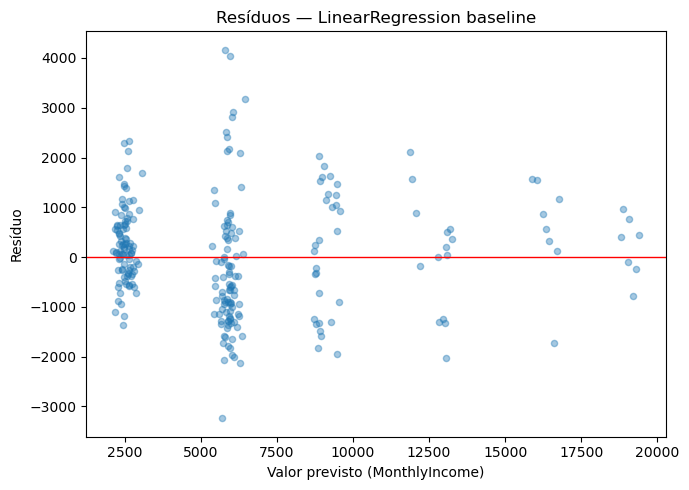

In [87]:
fig, ax = plt.subplots(figsize=(7, 5))
residuals = y_reg_test - y_reg_pred_lr
ax.scatter(y_reg_pred_lr, residuals, alpha=0.4, s=20)
ax.axhline(0, color="red", linewidth=1)
ax.set_xlabel("Valor previsto (MonthlyIncome)")
ax.set_ylabel("Resíduo")
ax.set_title("Resíduos — LinearRegression baseline")
plt.tight_layout()
plt.show()

A `LinearRegression` serve como modelo de referência para a tarefa de regressão. Dado que `JobLevel` e `MonthlyIncome` têm uma correlação de 0.95, é expectável que este baseline linear obtenha um R² elevado. O gráfico de resíduos permite verificar se existem padrões não capturados pelo modelo linear, como heterocedasticidade ou relações não lineares, que justifiquem o uso de modelos mais complexos na secção seguinte.

### Classificação — Baseline (LogisticRegression)

In [88]:
pipe_logreg = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("selector", SelectKBest(f_classif, k=20)),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=_random_state,
    )),
])

pipe_logreg.fit(X_clf_train, y_clf_train)
y_clf_pred_logreg = pipe_logreg.predict(X_clf_test)
y_clf_prob_logreg = pipe_logreg.predict_proba(X_clf_test)[:, 1]

baseline_clf = classification_metrics(
    y_clf_test, y_clf_pred_logreg, y_prob=y_clf_prob_logreg, label="LogisticRegression"
)

[LogisticRegression]
              precision    recall  f1-score   support

      No (0)       0.95      0.73      0.82       210
     Yes (1)       0.36      0.80      0.50        40

    accuracy                           0.74       250
   macro avg       0.65      0.76      0.66       250
weighted avg       0.86      0.74      0.77       250

ROC-AUC: 0.7969


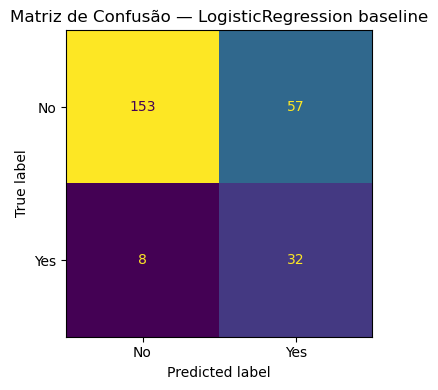

In [89]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, y_clf_pred_logreg,
    display_labels=["No", "Yes"],
    colorbar=False, ax=ax,
)
ax.set_title("Matriz de Confusão — LogisticRegression baseline")
plt.tight_layout()
plt.show()

A `LogisticRegression` com `class_weight='balanced'` serve como modelo de referência para a classificação. Este parâmetro ajusta os pesos das classes inversamente à sua frequência, penalizando mais os erros na classe minoritária ("Yes"). `max_iter=1000` é necessário para garantir convergência após o `StandardScaler`. A matriz de confusão mostra quantos falsos negativos o modelo comete, ou seja, funcionários que saíram mas foram classificados como "No", que são os erros com maior custo do ponto de vista de gestão de recursos humanos.

## Modelos

### Regressão — Comparação de Modelos

In [90]:
REG_MODELS = [
    ("RandomForest",     RandomForestRegressor(n_estimators=100, random_state=_random_state)),
    ("GradientBoosting", GradientBoostingRegressor(n_estimators=100, random_state=_random_state)),
]

# Seed from ## Treino — reuse the already-trained baseline, no redundant refit
reg_results = [{**baseline_reg, "Model": "LinearRegression"}]
reg_pipes   = {"LinearRegression": (pipe_lr, y_reg_pred_lr)}

for name, estimator in REG_MODELS:
    pipe = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("selector", SelectKBest(f_regression, k=20)),
        ("model", estimator),
    ])
    pipe.fit(X_reg_train, y_reg_train)
    y_pred = pipe.predict(X_reg_test)
    m = regression_metrics(y_reg_test, y_pred, label=name)
    m["Model"] = name
    reg_results.append(m)
    reg_pipes[name] = (pipe, y_pred)

reg_comparison = (
    pd.DataFrame(reg_results)
    .set_index("Model")[["R2", "RMSE", "MAE"]]
    .sort_values("R2", ascending=False)
)
print("\n── Tabela comparativa (teste) ──")
print(reg_comparison.round(4))

[RandomForest] R²=0.9399  RMSE=1034.38  MAE=769.58
[GradientBoosting] R²=0.9398  RMSE=1034.88  MAE=770.19

── Tabela comparativa (teste) ──
                      R2       RMSE       MAE
Model                                        
RandomForest      0.9399  1034.3829  769.5768
GradientBoosting  0.9398  1034.8843  770.1869
LinearRegression  0.9277  1134.4820  882.2249


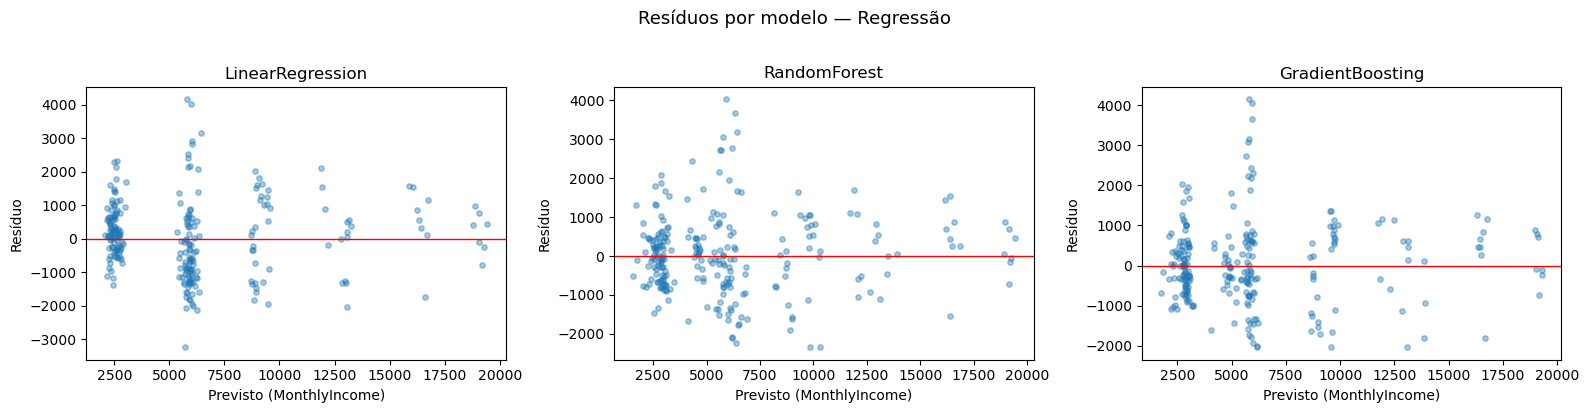

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, (pipe, y_pred)) in zip(axes, reg_pipes.items()):
    residuals = y_reg_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.4, s=15)
    ax.axhline(0, color="red", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Previsto (MonthlyIncome)")
    ax.set_ylabel("Resíduo")
plt.suptitle("Resíduos por modelo — Regressão", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Os três modelos são ordenados por R² decrescente. `RandomForest` e `GradientBoosting` capturam relações não lineares entre variáveis como `JobLevel`, `TotalWorkingYears` e `Age`, o que não é possível com regressão linear. Nos gráficos de resíduos, um padrão em leque no modelo linear (resíduos maiores para salários previstos mais altos) indica heterocedasticidade e justifica o uso dos modelos de ensemble. O modelo com melhor R² e menor RMSE avança para a fase de otimização.

### Classificação — Comparação de Modelos

In [92]:
CLF_MODELS = [
    ("RandomForest", RandomForestClassifier(
        class_weight="balanced", n_estimators=100, random_state=_random_state,
    )),
    # GradientBoosting não suporta class_weight — o desequilíbrio é tratado
    # indirectamente pela penalização sequencial de erros do boosting.
    ("GradientBoosting", GradientBoostingClassifier(
        n_estimators=100, random_state=_random_state,
    )),
]

# Seed from ## Treino — reuse the already-trained baseline, no redundant refit
clf_results = [{**baseline_clf, "Model": "LogisticRegression"}]
clf_pipes   = {"LogisticRegression": (pipe_logreg, y_clf_pred_logreg, y_clf_prob_logreg)}

for name, estimator in CLF_MODELS:
    pipe = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("selector", SelectKBest(f_classif, k=20)),
        ("model", estimator),
    ])
    pipe.fit(X_clf_train, y_clf_train)
    y_pred = pipe.predict(X_clf_test)
    y_prob = pipe.predict_proba(X_clf_test)[:, 1]
    m = classification_metrics(y_clf_test, y_pred, y_prob=y_prob, label=name)
    m["Model"] = name
    clf_results.append(m)
    clf_pipes[name] = (pipe, y_pred, y_prob)

clf_comparison = (
    pd.DataFrame(clf_results)
    .set_index("Model")[["F1", "Accuracy", "ROC-AUC"]]
    .sort_values("F1", ascending=False)
)
print("\n── Tabela comparativa (teste) ──")
print(clf_comparison.round(4))

[RandomForest]
              precision    recall  f1-score   support

      No (0)       0.87      0.99      0.92       210
     Yes (1)       0.73      0.20      0.31        40

    accuracy                           0.86       250
   macro avg       0.80      0.59      0.62       250
weighted avg       0.84      0.86      0.82       250

ROC-AUC: 0.7675
[GradientBoosting]
              precision    recall  f1-score   support

      No (0)       0.88      0.99      0.93       210
     Yes (1)       0.81      0.33      0.46        40

    accuracy                           0.88       250
   macro avg       0.85      0.66      0.70       250
weighted avg       0.87      0.88      0.86       250

ROC-AUC: 0.7968

── Tabela comparativa (teste) ──
                        F1  Accuracy  ROC-AUC
Model                                        
LogisticRegression  0.4961      0.74   0.7969
GradientBoosting    0.4643      0.88   0.7968
RandomForest        0.3137      0.86   0.7675


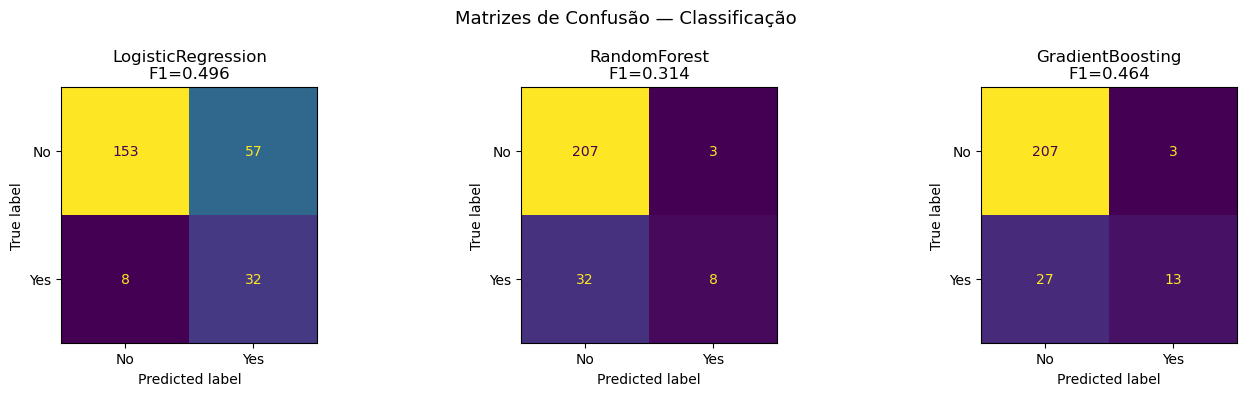

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, (pipe, y_pred, y_prob)) in zip(axes, clf_pipes.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_clf_test, y_pred,
        display_labels=["No", "Yes"],
        colorbar=False, ax=ax,
    )
    f1 = clf_comparison.loc[name, "F1"]
    ax.set_title(f"{name}\nF1={f1:.3f}")
plt.suptitle("Matrizes de Confusão — Classificação", fontsize=13)
plt.tight_layout()
plt.show()

Os modelos são ordenados por F1-score, que é a métrica do blind test. `GradientBoosting` não aceita `class_weight`, mas o algoritmo de boosting penaliza naturalmente exemplos mal classificados nas iterações seguintes, o que ajuda a lidar com o desequilíbrio. `RandomForest` com `class_weight='balanced'` tem penalização explícita da classe minoritária e é por isso o principal candidato para otimização.

As matrizes de confusão mostram o equilíbrio entre falsos negativos (funcionários que saíram mas foram previstos como "No") e falsos positivos. Do ponto de vista de negócio, os falsos negativos têm maior custo porque representam saídas que não foram antecipadas. O modelo com melhor F1-score avança para a fase de otimização.